# Rata copiilor neinscrisi la scoala si dezvoltarea economica
### Procesarea si Vizualizarea Datelor Folosind Python
**Stefan-Daniel Wagner**

---

## 1. Prezentarea problemei si motivatia

Accesul la educatie este unul dintre cei mai importanti indicatori de dezvoltare umana. Obiectivul de Dezvoltare Durabila nr. 4 (SDG 4) al ONU vizeaza asigurarea **educatiei de calitate, incluzive si echitabile** pentru toti pana in 2030.

Cu toate acestea, milioane de copii din intreaga lume raman in afara sistemului educational. Aceasta analiza investigheaza legatura dintre **nivelul de dezvoltare economica** al unei tari si **rata copiilor neinscrisi la scoala**, folosind date de la UNESCO si Banca Mondiala.

### Ipoteza de lucru

> **Rata copiilor neinscrisi in scoli este mai ridicata in tarile cu nivel de dezvoltare economic mai scazut, iar aceasta rata scade in timp odata cu cresterea economica.**

### Sursa datelor

- **Rata copiilor neinscrisi la scoala** (out-of-school rate, nivel primar) - UNESCO Institute for Statistics, via [Our World in Data](https://ourworldindata.org/grapher/children-not-in-school)
- **PIB per capita** (GDP per capita, PPP, dolari internationali constanti 2021) - World Bank, via [Our World in Data](https://ourworldindata.org/grapher/gdp-per-capita-worldbank)

### Variabile principale

| Variabila | Tip | Sursa |
|-----------|-----|-------|
| Rata out-of-school (nivel primar, ambele sexe) | Dependenta | UNESCO |
| PIB per capita (PPP) | Independenta | World Bank |
| Regiune geografica | Categoriala | OWID |

### Note metodologice

**Rata out-of-school (UNESCO).** Procentul copiilor de varsta scolara primara oficiala (definit per tara, tipic 6-11 ani) care **nu sunt inscrisi** la nicio forma de educatie - nici primar, nici pre-primar. Numaratorul include copii care n-au inceput vreodata scoala plus cei care au abandonat inainte de a se inscrie din nou. Nu surprinde absenteismul ulterior si nu masoara calitatea educatiei.

**PIB per capita (World Bank).** Exprimat in **dolari internationali constanti 2021, ajustat la paritatea puterii de cumparare** (PPP). PPP elimina distorsiunile de schimb valutar si diferentele de nivel al preturilor intre tari, ceea ce face PIB-ul comparabil real intre Niger si Norvegia. PIB nominal in USD ar fi indus in eroare (cosul de bunuri costa diferit local).

**De ce log-scale pe PIB?** PIB-ul variaza pe trei ordine de marime in dataset (~1.000 USD in Niger vs ~200.000 USD in Liechtenstein). Pe scala liniara, 99% din tari s-ar comprima la stanga si nu s-ar distinge pattern-uri. Logaritmul transforma "dublarea PIB-ului" intr-o distanta uniforma, ceea ce face vizibila relatia non-liniara a curbei OOS-PIB.

**Regiunile geografice OWID.** Clasificare continentala simpla folosita in Our World in Data; "America de Nord" include Mexic, Caraibe si America Centrala (nu doar SUA + Canada), ceea ce explica de ce media regionala apare mai mare decat ar sugera SUA singur.

## 2. Planul de lucru

1. **Import si curatare date** - descarcare CSV-uri de la OWID, merge pe tara + an, filtrare valori lipsa
2. **Analiza exploratorie** - statistici descriptive, distributii pe regiuni
3. **Vizualizare** (6 grafice, fiecare raspunde la o intrebare concreta):
   - *Unde e problema?* - Harta mondiala
   - *Cat de grava e situatia per regiune?* - Box plot pe regiuni
   - *Care sunt tarile cele mai afectate?* - Top tari
   - *Exista legatura cu bogatia?* - Scatter interactiv PIB vs. rata OOS + LOWESS
   - *Se imbunatateste situatia?* - Evolutie in timp pe regiuni
   - *Cat de mult s-a schimbat in 20 de ani?* - Comparatie prima vs. ultima masurare
4. **Analiza statistica**:
   - Ipoteze formale (H0/H1, alpha = 0.05)
   - Explicatia matematica a coeficientilor Pearson si Spearman
   - Scatter interactiv (Plotly, hover = detalii per tara)
   - Testarea ipotezei + interpretarea R2
5. **Interpretare si concluzii**

## 3. Implementare

### 3.1 Import librarii si descarcare date

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.colors as pcolors
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess
import requests, io, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 6)})

# Renderer plotly: emite si mimetype (pentru jupyter cu plotly extension),
# si HTML cu plotly.js incarcat din CDN (fallback robust pentru notebook 7).
pio.renderers.default = 'plotly_mimetype+notebook_connected'

# Paleta consistenta pentru regiuni (colorblind-safe, Wong 2011)
REGION_COLORS = {
    'Africa':        '#E69F00',
    'Asia':          '#56B4E9',
    'Europe':        '#009E73',
    'North America': '#CC79A7',
    'South America': '#D55E00',
    'Oceania':       '#0072B2',
}

# Pastram hover-ul interactiv, dar blocam pan/zoom ca graficele sa nu se deplaseze accidental.
PLOTLY_CONFIG = {
    'scrollZoom': False,
    'displayModeBar': True,
    'modeBarButtonsToRemove': [
        'zoom2d', 'pan2d', 'select2d', 'lasso2d',
        'zoomIn2d', 'zoomOut2d', 'autoScale2d', 'resetScale2d'
    ]
}


In [74]:
BASE = 'https://ourworldindata.org/grapher'
HEADERS = {'User-Agent': 'Mozilla/5.0 (research project)'}

# Snapshot local in data/. Daca exista, citim de acolo (deterministic, offline).
# Daca lipseste, descarcam de la OWID si scriem in data/ pentru rulari urmatoare.
import os
DATA_DIR = 'data'
SOURCES = {
    'oos': {
        'path': os.path.join(DATA_DIR, 'children-not-in-school-primary.csv'),
        'url':  f'{BASE}/children-not-in-school.csv?csvType=full&useColumnShortNames=false&metric_type=rate&level=primary&sex=both',
    },
    'gdp': {
        'path': os.path.join(DATA_DIR, 'gdp-per-capita-worldbank.csv'),
        'url':  f'{BASE}/gdp-per-capita-worldbank.csv?csvType=full&useColumnShortNames=false',
    },
}

def load_csv(key):
    s = SOURCES[key]
    if os.path.exists(s['path']):
        print(f"  {key}: citesc din {s['path']}")
        return pd.read_csv(s['path'])
    print(f"  {key}: descarc de la OWID -> {s['path']}")
    resp = requests.get(s['url'], headers=HEADERS, timeout=30)
    resp.raise_for_status()
    os.makedirs(DATA_DIR, exist_ok=True)
    with open(s['path'], 'wb') as f:
        f.write(resp.content)
    return pd.read_csv(io.StringIO(resp.text))

df_oos = load_csv('oos')
df_oos.columns = ['Entity', 'Code', 'Year', 'oos_rate']

df_gdp = load_csv('gdp')
df_gdp.columns = ['Entity', 'Code', 'Year', 'gdp_pc', 'region']

print(f'Educatie (primar): {df_oos.shape}')
print(f'PIB per capita:    {df_gdp.shape}')

  oos: citesc din data\children-not-in-school-primary.csv
  gdp: citesc din data\gdp-per-capita-worldbank.csv
Educatie (primar): (5400, 4)
PIB per capita:    (7240, 5)


In [75]:
# Merge pe Entity + Year
df = df_oos.merge(df_gdp[['Entity', 'Year', 'gdp_pc', 'region']],
                  on=['Entity', 'Year'], how='inner')

# Completare coduri ISO lipsa
code_map = df_gdp.dropna(subset=['Code']).drop_duplicates('Entity').set_index('Entity')['Code']
df['Code'] = df['Code'].fillna(df['Entity'].map(code_map))
df = df.dropna(subset=['Code'])
df['Year'] = df['Year'].astype(int)

# Snapshot cross-sectional: ultima raportare per tara in fereastra 2015-2023.
# Asta exclude ~22 tari cu raportari mai vechi de 2018 (Haiti 1997, DRC 1999, China 1997
# Nigeria 2010, Central African Republic 2012 etc) ca sa nu compar Romania 2023
# cu raportari de acum 25-30 de ani in box plot / scatter / top-15.
# Pentru analiza temporala (Grafic 5) si dumbbell (Grafic 6) folosesc tot dataset-ul.
WINDOW_MIN, WINDOW_MAX = 2018, 2023
df_window = df[df['Year'].between(WINDOW_MIN, WINDOW_MAX)]
latest = df_window.sort_values('Year').groupby('Entity').last().reset_index()

print(f'Dataset combinat: {df.shape}')
print(f'Tari unice: {df["Entity"].nunique()}')
print(f'Perioada: {df["Year"].min()} \u2013 {df["Year"].max()}')
print(f'Snapshot {WINDOW_MIN}-{WINDOW_MAX}: {len(latest)} tari')
print(f'Regiuni: {sorted(df["region"].dropna().unique())}')
df.head()

Dataset combinat: (3793, 6)
Tari unice: 196
Perioada: 1990 – 2024
Snapshot 2018-2023: 174 tari
Regiuni: ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']


,Entity,Code,Year,oos_rate,gdp_pc,region
0,Albania,ALB,1999,3.06716,6086.0090,Europe
1,Albania,ALB,2003,1.33887,8025.2812,Europe
2,Albania,ALB,2004,3.56275,8483.2940,Europe
3,Albania,ALB,2008,6.73451,11056.3520,Europe
4,Albania,ALB,2009,5.63091,11430.6220,Europe


### 3.2 Statistici descriptive

In [76]:
df[['oos_rate', 'gdp_pc']].rename(columns={
    'oos_rate': 'Rata OOS (%)',
    'gdp_pc':   'PIB/capita (USD)'
}).describe().round(2)

,Rata OOS (%),PIB/capita (USD)
count,3793.00,3793.00
mean,9.60,24195.27
std,13.54,25013.16
min,0.00,510.82
25%,1.28,5760.80
50%,4.42,14853.67
75%,11.05,36563.62
max,79.78,174569.52


In [77]:
region_stats = (
    latest
    .groupby('region')
    .agg(
        nr_tari=('Entity', 'count'),
        oos_mediana=('oos_rate', 'median'),
        oos_medie=('oos_rate', 'mean'),
        gdp_mediana=('gdp_pc', 'median')
    )
    .round(2)
    .sort_values('oos_mediana', ascending=False)
    .rename(columns={
        'nr_tari':     'Nr. tari',
        'oos_mediana': 'OOS mediana (%)',
        'oos_medie':   'OOS medie (%)',
        'gdp_mediana': 'PIB mediana (USD)',
    })
)
region_stats

,Nr. tari,OOS mediana (%),OOS medie (%),PIB mediana (USD)
region,,,,
Africa,37,9.94,15.10,4304.76
North America,24,6.59,9.11,24230.12
South America,11,4.16,6.91,18458.72
Asia,41,3.99,6.37,17866.40
Oceania,14,2.57,6.28,6983.64
Europe,42,1.38,2.45,47650.01


**Europa si Africa**, la cele doua capete ale spectrului PIB, sustin clar ipoteza: Africa cu mediana cea mai ridicata (~9.9% OOS, mean ~15%) si PIB mediu cel mai mic, Europa cu mediana cea mai mica (~1.4%) si PIB mediu cel mai mare. Asia, Oceania si America de Sud cad in zona intermediara, in linie cu PIB-ul lor.

**America de Nord rupe pattern-ul**: mediana ~6.6% (mean ~9.1%) in ciuda PIB-ului regional ridicat. Cauza: clasificarea OWID include Mexic, Caraibe si America Centrala, nu doar SUA + Canada. Tarile cu PIB mai mic din regiune (Honduras, Nicaragua, Haiti) trag mediana in sus, in timp ce mediile PIB sunt umflate de SUA si Canada. Regiunea nu e o unitate omogena.

### 3.3 Vizualizari

#### Grafic 1 - Unde e problema? Harta mondiala

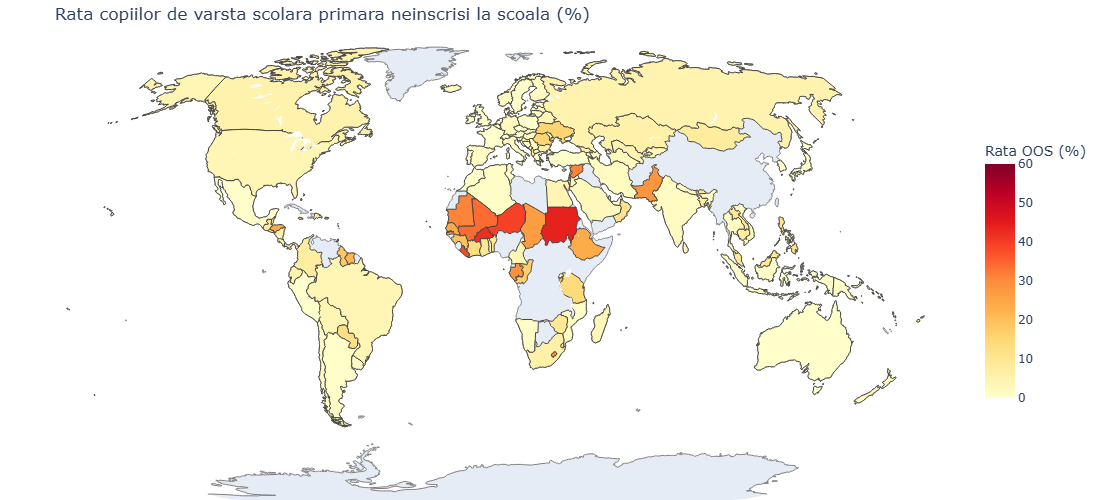

In [78]:
fig = px.choropleth(
    latest,
    locations='Code',
    color='oos_rate',
    hover_name='Entity',
    hover_data={
        'oos_rate': ':.1f',
        'gdp_pc':   ':,.0f',
        'Year':     True,
        'Code':     False,
    },
    color_continuous_scale='YlOrRd',
    range_color=[0, 60],
    labels={
        'oos_rate': 'Rata OOS (%)',
        'gdp_pc':   'PIB/capita ($)',
    },
    title='Rata copiilor de varsta scolara primara neinscrisi la scoala (%)'
)
fig.update_geos(
    projection_type='natural earth',
    showframe=False,
    showcoastlines=True, coastlinecolor='gray',
)
fig.update_layout(
    width=900, height=500,
    margin=dict(l=0, r=0, t=40, b=0),
    coloraxis_colorbar=dict(x=1.0, len=0.6)
)
fig.show(config={**PLOTLY_CONFIG, 'scrollZoom': True})

Harta releva o concentrare clara a ratelor ridicate in **Africa** si parti din **Asia**, in timp ce Europa, America de Nord si Asia de Est au rate aproape de zero. Distributia geografica reflecta nivelul de dezvoltare economica.

#### Grafic 2 - Cat de grava e situatia per regiune? Box plot

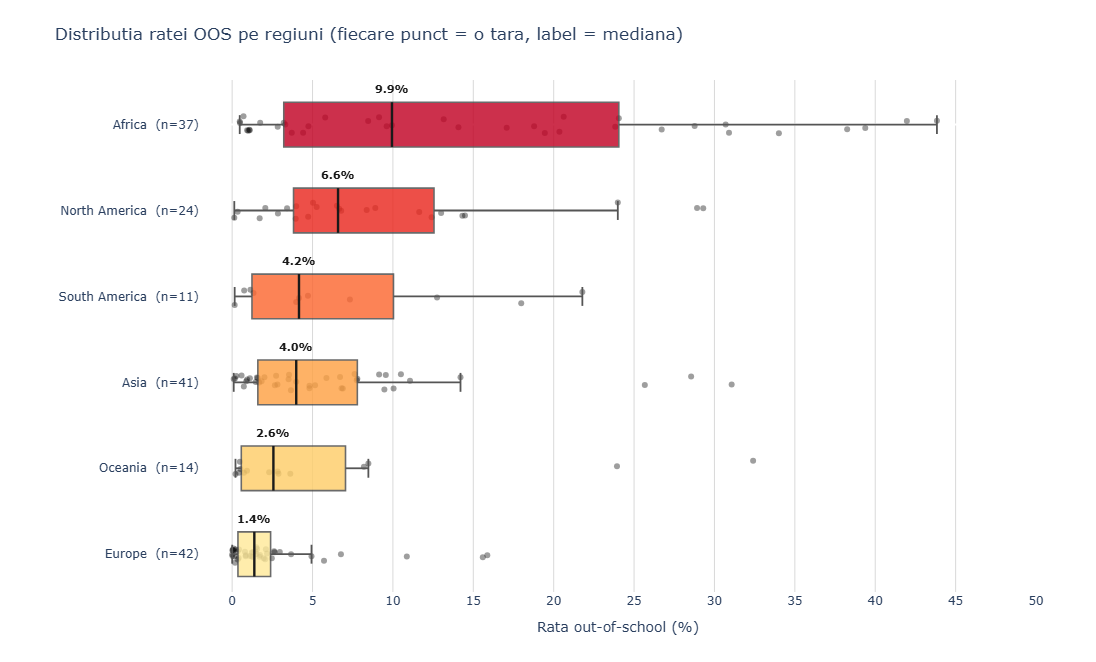

In [79]:
order = (latest.groupby('region')['oos_rate']
         .median().sort_values(ascending=False).index.tolist())

box_data = latest.dropna(subset=['oos_rate', 'region']).copy()
colors = sns.color_palette('YlOrRd_r', n_colors=len(order)).as_hex()

# Label-uri Y cu numarul de tari per regiune
counts_per_region = box_data.groupby('region').size().to_dict()
y_labels = [f'{r}  (n={counts_per_region[r]})' for r in order]

fig = go.Figure()
box_height = 0.52
cap_height = 0.22

for i, (region, color) in enumerate(zip(order, colors)):
    subset = box_data[box_data['region'] == region].copy()
    values = subset['oos_rate'].dropna()
    q1, median, q3 = values.quantile([0.25, 0.50, 0.75])
    iqr = q3 - q1
    lower_whisker = values[values >= q1 - 1.5 * iqr].min()
    upper_whisker = values[values <= q3 + 1.5 * iqr].max()
    actual_max = values.max()

    # Cutia: intervalul interquartilic Q1-Q3, adica 50% din tarile regiunii.
    fig.add_shape(
        type='rect', x0=q1, x1=q3, y0=i - box_height / 2, y1=i + box_height / 2,
        line=dict(color='#4a4a4a', width=1.6), fillcolor=color, opacity=0.82
    )
    # Mediana: linia verticala din interiorul cutiei.
    fig.add_shape(
        type='line', x0=median, x1=median, y0=i - box_height / 2, y1=i + box_height / 2,
        line=dict(color='#1a1a1a', width=2.4)
    )
    # Mustati
    fig.add_shape(
        type='line', x0=lower_whisker, x1=q1, y0=i, y1=i,
        line=dict(color='#555555', width=1.8)
    )
    fig.add_shape(
        type='line', x0=q3, x1=upper_whisker, y0=i, y1=i,
        line=dict(color='#555555', width=1.8)
    )
    fig.add_shape(
        type='line', x0=lower_whisker, x1=lower_whisker,
        y0=i - cap_height / 2, y1=i + cap_height / 2,
        line=dict(color='#555555', width=1.8)
    )
    fig.add_shape(
        type='line', x0=upper_whisker, x1=upper_whisker,
        y0=i - cap_height / 2, y1=i + cap_height / 2,
        line=dict(color='#555555', width=1.8)
    )

    # Label cu valoarea medianei, deasupra cutiei (y reverse -> minus = sus)
    fig.add_annotation(
        x=median, y=i - box_height / 2 - 0.16,
        text=f'<b>{median:.1f}%</b>',
        showarrow=False,
        font=dict(size=11, color='#1a1a1a'),
        xanchor='center',
    )

    # Puncte (jitter) - toate vizibile, fara clipping
    rng = np.random.default_rng(100 + i)
    jitter = rng.uniform(-0.10, 0.10, len(subset))
    fig.add_trace(go.Scatter(
        x=subset['oos_rate'],
        y=np.full(len(subset), i) + jitter,
        mode='markers',
        marker=dict(color='rgba(0,0,0,0.38)', size=6),
        text=subset['Entity'],
        customdata=subset[['Year', 'gdp_pc']].values,
        hovertemplate=(
            '<b>%{text}</b><br>'
            f'Regiune: {region}<br>'
            'Rata OOS: %{x:.1f}%<br>'
            'An: %{customdata[0]:.0f}<br>'
            'PIB/capita: $%{customdata[1]:,.0f}'
            '<extra></extra>'
        ),
        showlegend=False
    ))

    # Hover invizibil peste mediana, ca sa apara stats la trecere
    fig.add_trace(go.Scatter(
        x=[median], y=[i], mode='markers', marker=dict(size=18, opacity=0),
        hovertemplate=(
            f'<b>{region}</b><br>'
            f'Q1: {q1:.1f}%<br>'
            f'Mediana: {median:.1f}%<br>'
            f'Q3: {q3:.1f}%<br>'
            f'Mustati: {lower_whisker:.1f}% - {upper_whisker:.1f}%<br>'
            f'Max: {actual_max:.1f}%<br>'
            f'Nr. tari: {len(subset)}'
            '<extra></extra>'
        ),
        showlegend=False
    ))

fig.update_layout(
    title='Distributia ratei OOS pe regiuni (fiecare punct = o tara, label = mediana)',
    width=1280, height=650,
    plot_bgcolor='white',
    dragmode=False,
    hovermode='closest',
    margin=dict(l=200, r=60, t=80, b=70),
    xaxis=dict(
        title='Rata out-of-school (%)',
        range=[-2, 50],
        dtick=5,
        showgrid=True,
        gridcolor='#d9d9d9',
        zeroline=False,
        fixedrange=True
    ),
    yaxis=dict(
        tickmode='array',
        tickvals=list(range(len(order))),
        ticktext=y_labels,
        autorange='reversed',
        showgrid=False,
        fixedrange=True
    )
)
fig.show(config=PLOTLY_CONFIG)

Box plot-ul rezuma distributia fiecarei regiuni, iar punctele arata tarile individuale. Linia verticala din interiorul fiecarei cutii este **mediana** ($Q_2$): jumatate dintre tarile regiunii sunt sub acea valoare si jumatate peste. Cutia propriu-zisa acopera intervalul dintre **$Q_1$ si $Q_3$**: $Q_1$ este valoarea sub care se afla 25% dintre tari, iar $Q_3$ este valoarea sub care se afla 75% dintre tari. Deci cutia contine 50% dintre tarile regiunii.

Latimea cutiei se numeste **IQR** (*interquartile range*) si se calculeaza astfel:

$$IQR = Q_3 - Q_1$$

Mustatile merg pana la cele mai indepartate valori care inca se afla in intervalul:

$$[Q_1 - 1.5 \cdot IQR,\ Q_3 + 1.5 \cdot IQR]$$

Punctele aflate dincolo de mustati sunt **outlieri statistici**: tari care se abat mult de la restul regiunii. De exemplu, daca Moldova apare mult in dreapta mustatii pentru Europa, interpretarea este ca rata ei OOS este neobisnuit de ridicata comparativ cu majoritatea tarilor europene. Nu inseamna automat ca datele sunt gresite, ci ca tara respectiva nu seamana cu distributia tipica a regiunii.

Graficul arata ca Africa nu are doar mediana cea mai ridicata, ci si cea mai mare dispersie: exista tari africane cu rate foarte mari, dar si tari apropiate de zero. Europa este concentrata aproape de zero, cu cateva exceptii izolate. De aceea box plot-ul este util aici: nu arata doar media regionala, ci si cat de inegale sunt tarile din interiorul aceleiasi regiuni.

#### Grafic 3 - Care sunt tarile cele mai afectate? Top 15

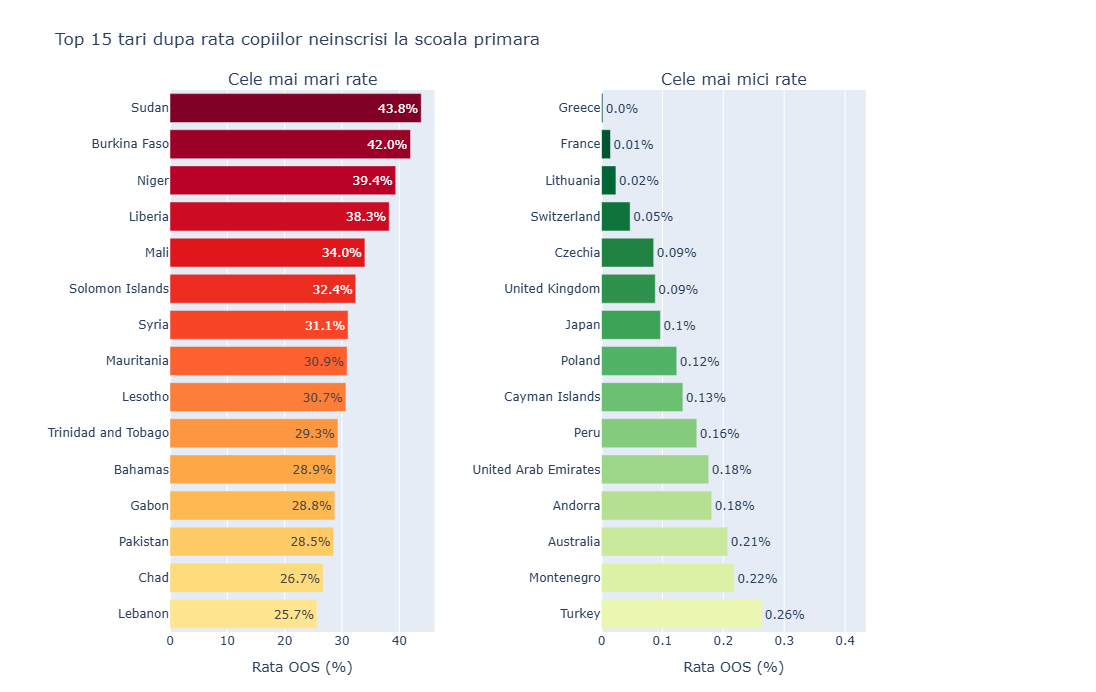

In [80]:
top15 = latest.nlargest(15, 'oos_rate').sort_values('oos_rate')
bottom15 = (latest[latest['oos_rate'] > 0]
            .nsmallest(15, 'oos_rate')
            .sort_values('oos_rate', ascending=False))

n = 15
reds   = pcolors.sample_colorscale('YlOrRd', [(i + 3) / (n + 2) for i in range(n)])
greens = pcolors.sample_colorscale('YlGn',   [(i + 3) / (n + 2) for i in range(n)])

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Cele mai mari rate', 'Cele mai mici rate'],
                    horizontal_spacing=0.24)

fig.add_trace(go.Bar(
    x=top15['oos_rate'], y=top15['Entity'],
    orientation='h', marker_color=reds,
    text=top15['oos_rate'].round(1).astype(str) + '%',
    textposition='inside', insidetextanchor='end',
    cliponaxis=False,
    hovertemplate='<b>%{y}</b><br>Rata OOS: %{x:.1f}%<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=bottom15['oos_rate'], y=bottom15['Entity'],
    orientation='h', marker_color=greens,
    text=bottom15['oos_rate'].round(2).astype(str) + '%',
    textposition='outside',
    cliponaxis=False,
    hovertemplate='<b>%{y}</b><br>Rata OOS: %{x:.2f}%<extra></extra>'
), row=1, col=2)

fig.update_layout(
    title_text='Top 15 tari dupa rata copiilor neinscrisi la scoala primara',
    showlegend=False,
    width=1280, height=680,
    dragmode=False,
    margin=dict(l=170, r=230, t=90, b=60)
)
fig.update_xaxes(title_text='Rata OOS (%)', fixedrange=True, row=1, col=1)
fig.update_xaxes(
    title_text='Rata OOS (%)',
    range=[0, bottom15['oos_rate'].max() * 1.65],
    fixedrange=True,
    row=1, col=2
)
fig.update_yaxes(automargin=True, fixedrange=True)
fig.show(config=PLOTLY_CONFIG)

Contrastul este de **doua ordine de marime**: tarile cele mai afectate au rate de zeci de procente, in timp ce tarile cu cele mai mici rate au valori sub 1%. Tarile cu rate ridicate sunt predominant din Africa, cele cu rate mici din Europa si Asia de Est.

#### Grafic 4 - Exista legatura cu bogatia? Scatter + LOWESS

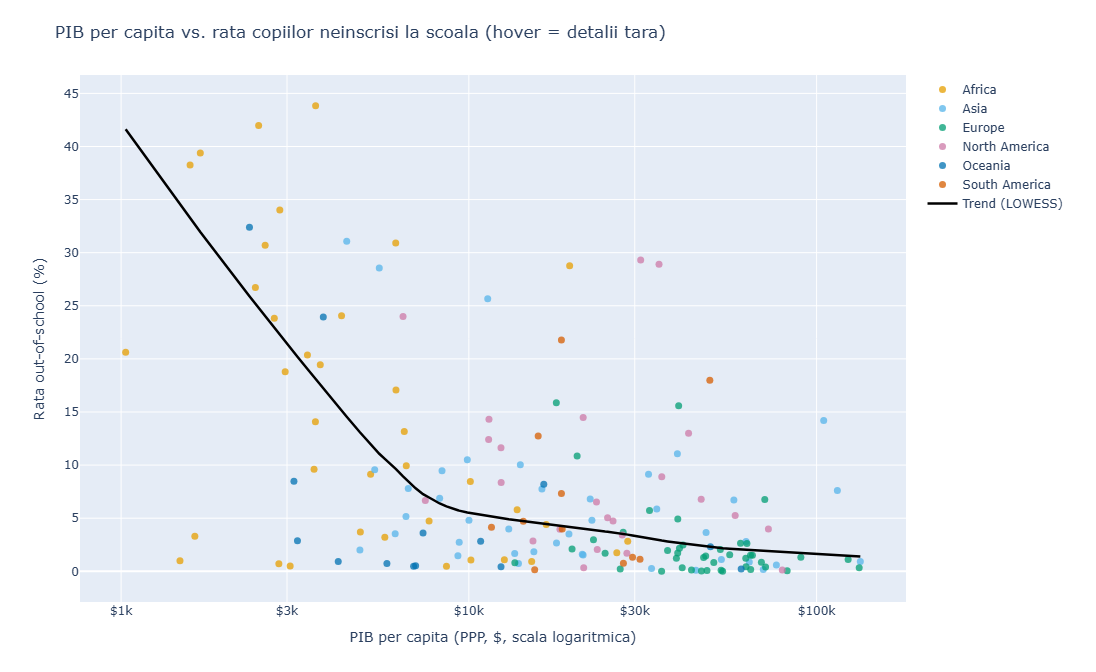

In [81]:
plot_data = latest.dropna(subset=['oos_rate', 'gdp_pc', 'region']).copy()

# Curba LOWESS - trend non-parametric (nu presupune nicio forma)
x_log = np.log10(plot_data['gdp_pc'].values)
y_vals = plot_data['oos_rate'].values
sort_idx = np.argsort(x_log)
smoothed = lowess(y_vals[sort_idx], x_log[sort_idx], frac=0.5)

fig = go.Figure()

for region in sorted(plot_data['region'].unique()):
    mask = plot_data['region'] == region
    subset = plot_data[mask]
    fig.add_trace(go.Scatter(
        x=subset['gdp_pc'], y=subset['oos_rate'],
        mode='markers',
        name=region,
        marker=dict(size=7, color=REGION_COLORS.get(region, '#888'), opacity=0.75),
        text=subset['Entity'],
        customdata=subset[['gdp_pc', 'oos_rate', 'Year']].values,
        hovertemplate=(
            '<b>%{text}</b><br>'
            'PIB/capita: $%{customdata[0]:,.0f}<br>'
            'Rata OOS: %{customdata[1]:.1f}%<br>'
            'An: %{customdata[2]:.0f}'
            '<extra></extra>'
        )
    ))

fig.add_trace(go.Scatter(
    x=10**smoothed[:, 0], y=smoothed[:, 1],
    mode='lines', name='Trend (LOWESS)',
    line=dict(color='black', width=2.5),
    hoverinfo='skip'
))

fig.update_layout(
    title='PIB per capita vs. rata copiilor neinscrisi la scoala (hover = detalii tara)',
    xaxis=dict(
        type='log', title='PIB per capita (PPP, $, scala logaritmica)',
        tickvals=[1000, 3000, 10000, 30000, 100000],
        ticktext=['$1k', '$3k', '$10k', '$30k', '$100k'],
        fixedrange=True,
    ),
    yaxis=dict(title='Rata out-of-school (%)', fixedrange=True),
    legend=dict(x=1.02, y=1, xanchor='left', bgcolor='rgba(255,255,255,0.85)'),
    width=1120, height=660,
    dragmode=False,
    hovermode='closest',
    margin=dict(l=80, r=190, t=75, b=70)
)
fig.show(config=PLOTLY_CONFIG)

**Acesta este graficul central al analizei mele.** Vad in scatter o relatie negativa clara: tarile cu PIB per capita mai ridicat tind sa aiba rate mai mici de copii neinscrisi. Curba LOWESS (o tehnica non-parametrica ce nu presupune o forma predefinita) arata ca **relatia nu e pur liniara** - asocierea dintre PIB si rata OOS este mai pronuntata in tarile sarace, iar dupa un prag de aproximativ 10.000 USD per capita, rata se stabilizeaza aproape de zero.

Hover-ul permite identificarea unor exceptii interesante: tari cu PIB scazut, dar rate OOS mici (posibil asociate cu politici educationale mai eficiente), si tari cu PIB relativ ridicat, dar rate OOS inca notabile.

#### Grafic 5 - Se imbunatateste situatia? Evolutie in timp

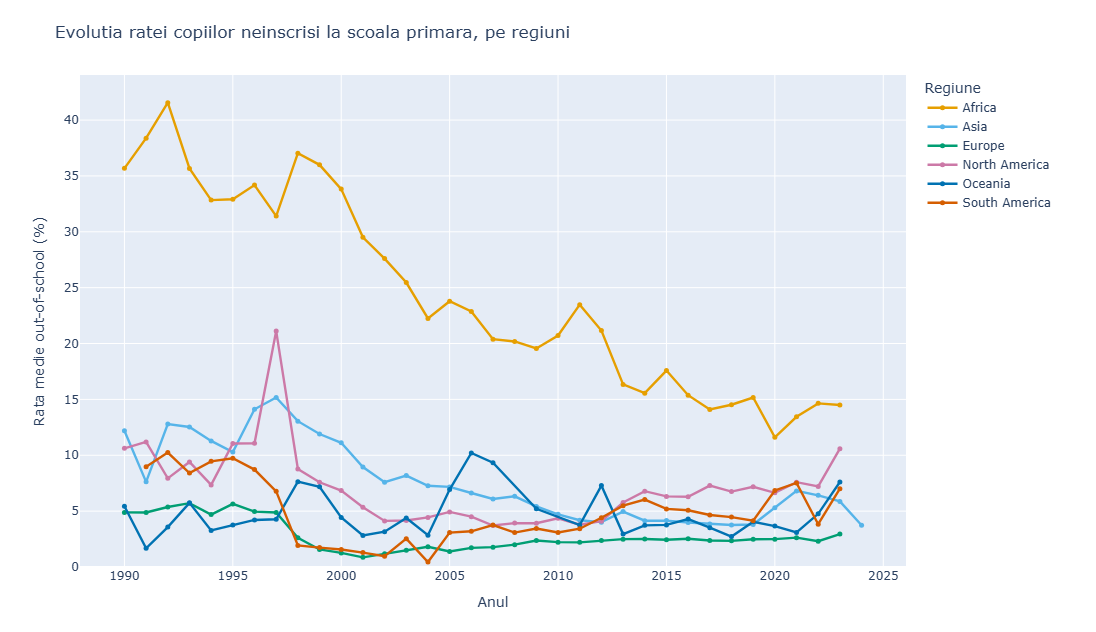

In [82]:
region_time = (
    df.dropna(subset=['oos_rate', 'region'])
    .groupby(['region', 'Year'])
    .agg(oos_mean=('oos_rate', 'mean'), nr_tari=('Entity', 'nunique'))
    .reset_index()
)
region_time = region_time[region_time['nr_tari'] >= 3]

fig = px.line(
    region_time,
    x='Year', y='oos_mean',
    color='region',
    color_discrete_map=REGION_COLORS,
    markers=True,
    hover_data={'nr_tari': True, 'region': False},
    labels={
        'oos_mean':  'Rata medie out-of-school (%)',
        'Year':      'Anul',
        'region':    'Regiune',
        'nr_tari':   'Nr. tari',
    },
    title='Evolutia ratei copiilor neinscrisi la scoala primara, pe regiuni'
)
fig.update_traces(marker=dict(size=5), line=dict(width=2.4))

fig.update_layout(
    width=1120, height=620,
    legend=dict(title='Regiune', x=1.02, y=1, xanchor='left'),
    xaxis=dict(fixedrange=True),
    yaxis=dict(rangemode='tozero', fixedrange=True),
    dragmode=False,
    margin=dict(l=80, r=190, t=75, b=65)
)
fig.show(config=PLOTLY_CONFIG)

**Trend descendent in toate regiunile** - datele indica o imbunatatire globala a inscrierii copiilor la scoala. Totusi, decalajul ramane mare: Africa porneste de la rate mult mai ridicate si, desi scade, ramane peste celelalte regiuni.

#### Grafic 6 - Cat de mult s-a schimbat in 20 de ani? Dumbbell chart

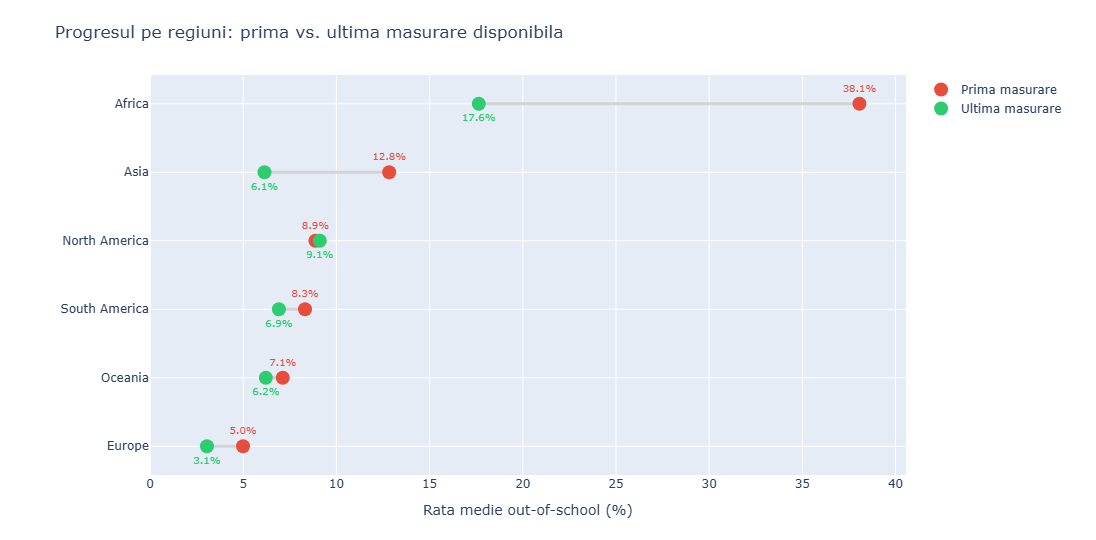

In [83]:
first_year = df.sort_values('Year').groupby(['region', 'Entity']).first().reset_index()
last_year  = df.sort_values('Year').groupby(['region', 'Entity']).last().reset_index()

dumbbell = pd.DataFrame({
    'region': first_year.groupby('region')['oos_rate'].mean().index,
    'prima':  first_year.groupby('region')['oos_rate'].mean().values,
    'ultima': last_year.groupby('region')['oos_rate'].mean().values,
})
dumbbell['schimbare'] = dumbbell['ultima'] - dumbbell['prima']
dumbbell = dumbbell.sort_values('prima', ascending=True).reset_index(drop=True)

fig = go.Figure()

# Linii de legatura
x_lines, y_lines = [], []
for _, row in dumbbell.iterrows():
    x_lines.extend([row['prima'], row['ultima'], None])
    y_lines.extend([row['region'], row['region'], None])

fig.add_trace(go.Scatter(
    x=x_lines, y=y_lines, mode='lines',
    line=dict(color='lightgray', width=3),
    showlegend=False, hoverinfo='skip'
))

fig.add_trace(go.Scatter(
    x=dumbbell['prima'], y=dumbbell['region'],
    mode='markers+text', name='Prima masurare',
    marker=dict(size=14, color='#E74C3C'),
    text=dumbbell['prima'].round(1).astype(str) + '%',
    textposition='top center',
    textfont=dict(color='#E74C3C', size=10),
    hovertemplate='<b>%{y}</b><br>Prima masurare: %{x:.1f}%<extra></extra>'
))

fig.add_trace(go.Scatter(
    x=dumbbell['ultima'], y=dumbbell['region'],
    mode='markers+text', name='Ultima masurare',
    marker=dict(size=14, color='#2ECC71'),
    text=dumbbell['ultima'].round(1).astype(str) + '%',
    textposition='bottom center',
    textfont=dict(color='#2ECC71', size=10),
    hovertemplate='<b>%{y}</b><br>Ultima masurare: %{x:.1f}%<extra></extra>'
))

fig.update_layout(
    title='Progresul pe regiuni: prima vs. ultima masurare disponibila',
    xaxis=dict(title='Rata medie out-of-school (%)', rangemode='tozero', fixedrange=True),
    yaxis=dict(categoryorder='array', categoryarray=dumbbell['region'].tolist(), fixedrange=True),
    width=1050, height=540,
    legend=dict(x=1.02, y=1, xanchor='left'),
    dragmode=False,
    hovermode='closest',
    margin=dict(r=190, l=150, t=75, b=65)
)
fig.show(config=PLOTLY_CONFIG)

Dumbbell chart-ul arata progresul pe regiuni. Cinci din sase regiuni au rate mai mici la ultima masurare decat la prima. Africa a facut cel mai mare progres in valoare absoluta (-20.4 puncte procentuale), dar ramane la cel mai ridicat nivel (17.6%). Europa are rata cea mai mica (3.1%). America de Nord este exceptia: rata medie a stagnat (8.9% -> 9.1%) - posibila cauza este compozitia esantionului OWID pentru regiune (include si Mexic, Caraibe, America Centrala), care s-a modificat in timp.

### 3.4 Analiza statistica

#### Ipoteze formale

Inainte sa calculez coeficientii, formulez explicit ce testez:

- **H$_0$ (ipoteza nula):** Nu exista corelatie intre log(PIB per capita) si rata out-of-school: $\rho = 0$
- **H$_1$ (ipoteza alternativa):** Exista o corelatie negativa: tarile cu PIB per capita mai ridicat tind sa aiba rate mai mici: $\rho < 0$

Nivel de semnificatie ales: **$\alpha = 0.05$**

---

#### De ce doua teste diferite?

**Pearson (r)**

Masoara cat de bine se aproximeaza relatia printr-o linie dreapta. Formula este raportul dintre covarianta si produsul abaterilor standard:

$$r = \frac{\text{cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$

Cu alte cuvinte: cat de mult variaza X si Y impreuna, normalizat sa fie intotdeauna intre -1 si +1. Un $r = -1$ inseamna corelatie negativa perfecta, $r = 0$ inseamna nicio relatie liniara, $r = +1$ corelatie pozitiva perfecta.

**Presupune o relatie liniara** intre X si Y. De aceea aplicam `log10(PIB)` inainte de calcul - transformam o relatie curbilinie intr-una aproximativ liniara.

**Spearman ($\rho_s$)**

Nu lucreaza cu valorile brute, ci cu **rangurile** lor. Fiecarei tari i se atribuie un rang (1 = cea mai saraca, n = cea mai bogata), si Pearson se aplica pe aceste ranguri. O formula echivalenta, in forma clasica fara egalitati de rang, este:

$$\rho_s = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$

unde $d_i$ = diferenta dintre rangul lui $x_i$ si rangul lui $y_i$. In implementarea efectiva, `scipy.stats.spearmanr` trateaza automat egalitatile de rang prin ranguri medii.

Nu presupune liniaritate - captureaza orice relatie **monotona** (daca X creste, Y scade consistent, indiferent daca e linie dreapta sau curba). De aceea il folosim ca verificare independenta.

**Ce ne spune diferenta dintre cele doua?** Daca $|\rho_s| > |r|$ pe aceleasi date, relatia e mai degraba monotona dar neliniara. Daca sunt aproape egale, transformarea logaritmica a redus mult curbura relatiei.

In [84]:
from scipy.stats import pearsonr, spearmanr

analysis_data = latest.dropna(subset=['oos_rate', 'gdp_pc'])
log_gdp = np.log10(analysis_data['gdp_pc'])
oos = analysis_data['oos_rate']

r_pearson,  p_pearson  = pearsonr(log_gdp, oos, alternative='less')
r_spearman, p_spearman = spearmanr(analysis_data['gdp_pc'], oos, alternative='less')

alpha = 0.05

print('=' * 60)
print('TESTAREA IPOTEZEI: PIB per capita vs. Rata out-of-school')
print('=' * 60)
print(f'\nH0: rho = 0  |  H1: rho < 0  |  alpha = {alpha}')

print('\n--- Pearson r (log GDP vs OOS) ---')
print(f'  r       = {r_pearson:.4f}')
print(f'  p-value = {p_pearson:.2e}')
print(f'  Decizie : {"RESPINGEM H0" if p_pearson < alpha else "Nu respingem H0"} '
      f'(p {"<" if p_pearson < alpha else ">"} alpha)')

print('\n--- Spearman rho (GDP vs OOS) ---')
print(f'  rho     = {r_spearman:.4f}')
print(f'  p-value = {p_spearman:.2e}')
print(f'  Decizie : {"RESPINGEM H0" if p_spearman < alpha else "Nu respingem H0"} '
      f'(p {"<" if p_spearman < alpha else ">"} alpha)')

r2 = r_pearson ** 2
print(f'\n--- Puterea explicativa (Pearson) ---')
print(f'  R\u00b2 = {r2:.4f}')
print(f'  log(PIB/cap) este asociat cu {r2*100:.1f}% din variatia ratei OOS')
print(f'  Restul de {(1-r2)*100:.1f}% ramane asociat cu alti factori (politici, stabilitate, etc.)')

print('\n--- Comparatie Pearson vs Spearman ---')
diff = abs(r_spearman) - abs(r_pearson)
if diff > 0.02:
    concluzie_comp = 'Spearman > Pearson: relatia e monotona dar neliniara'
elif diff < -0.02:
    concluzie_comp = 'Pearson > Spearman: log-transformarea a redus mult curbura'
else:
    concluzie_comp = 'Valori aproape egale: log-transformarea si rangurile ajung la acelasi loc'
print(f'  |r_pearson|  = {abs(r_pearson):.4f}')
print(f'  |r_spearman| = {abs(r_spearman):.4f}')
print(f'  -> {concluzie_comp}')

print(f'\nNumar de tari in esantion: {len(analysis_data)}')

TESTAREA IPOTEZEI: PIB per capita vs. Rata out-of-school

H0: rho = 0  |  H1: rho < 0  |  alpha = 0.05

--- Pearson r (log GDP vs OOS) ---
  r       = -0.5241
  p-value = 5.75e-14
  Decizie : RESPINGEM H0 (p < alpha)

--- Spearman rho (GDP vs OOS) ---
  rho     = -0.4904
  p-value = 3.25e-12
  Decizie : RESPINGEM H0 (p < alpha)

--- Puterea explicativa (Pearson) ---
  R² = 0.2747
  log(PIB/cap) este asociat cu 27.5% din variatia ratei OOS
  Restul de 72.5% ramane asociat cu alti factori (politici, stabilitate, etc.)

--- Comparatie Pearson vs Spearman ---
  |r_pearson|  = 0.5241
  |r_spearman| = 0.4904
  -> Pearson > Spearman: log-transformarea a redus mult curbura

Numar de tari in esantion: 174


Ambele teste confirma ca putem **respinge H₀** cu incredere: p-value-urile sunt mult sub pragul α = 0.05 ales. Deoarece ipoteza alternativa este directionala ($\rho < 0$), testele au fost rulate unilateral, in sensul unei corelatii negative.

**Ce inseamna r = -0.524 pe log-GDP?** Pearson masoara cat de bine urmaresc datele o linie dreapta atunci cand PIB-ul este pe scala logaritmica. Un r de -0.524 indica o corelatie negativa moderata-spre-puternica: nu perfecta, dar suficient de clara pentru a sustine ipoteza. R² = 27.5%: intr-un model liniar simplu pe log(PIB), aproximativ un sfert din variatia ratelor de neinscolare este asociata cu nivelul economic al tarii.

**De ce |Pearson| > |Spearman| in acest caz?** Pearson pe log-PIB (0.524) e mai mare decat Spearman pe PIB brut (0.490). Asta inseamna ca **transformarea logaritmica a PIB-ului liniarizeaza relatia mai bine** decat o face pur si simplu rangul: dupa log, relatia urmeaza o linie aproape dreapta. Daca ar fi fost invers (|Spearman| > |Pearson|), ar fi insemnat ca relatia e monotona dar inca neliniara dupa transformarea log. Cele doua metode masoara acelasi tipar din perspective diferite, iar apropierea rezultatelor intareste concluzia.

**Curba LOWESS din grafic** adauga informatia pe care corelatia singura nu o ofera: asocierea dintre PIB si rata OOS nu este uniforma. Sub aproximativ 5.000 USD per capita, cresterile PIB-ului sunt asociate cu scaderi mari ale ratei OOS. Peste aproximativ 10.000 USD per capita, rata se plateaza aproape de zero si variatia ramasa devine mult mai mica.

## 4. Interpretarea rezultatelor

### Ce spun numerele

Coeficientul Pearson de -0.524 calculat pe log(PIB) si coeficientul Spearman de -0.490 calculat pe PIB brut sunt foarte apropiati. Ambele metode masoara acelasi fenomen din unghiuri diferite si ajung la aceeasi concluzie: exista o asociere negativa sistematica intre nivelul economic al unei tari si rata copiilor ramasi in afara scolii.

Asta nu inseamna ca bogatia "cauzeaza" direct scolarizarea. PIB-ul per capita este un proxy condensat pentru mai multi factori care merg adesea in paralel: stabilitate politica, investitii in infrastructura scolara, acces la transport, munca copiilor in agricultura de subzistenta. Corelatia arata ca aceste fenomene apar impreuna, dar nu stabileste direct mecanismul cauzal.

### Relatia nu e liniara - si asta conteaza

Daca relatia ar fi strict liniara pe scala logaritmica, fiecare dublare a PIB-ului ar fi asociata cu aceeasi scadere medie a ratei OOS, indiferent de nivelul de start. Curba LOWESS pe care am trasat-o arata ca datele nu urmeaza perfect aceasta forma.

In tarile cu PIB sub 5.000 USD/capita, am observat ca cresterile PIB-ului sunt asociate cu diferente mari ale ratei OOS: in zona aceasta a graficului, o trecere de la aproximativ 1.000 la 3.000 USD per capita corespunde unei scaderi vizibile a ratei. In tarile cu PIB peste 10.000 USD/capita, rata este deja aproape de zero si mai are putin "spatiu" statistic de scadere.

Aceasta forma de curba cu "saturatie" este importanta pentru interpretare: asocierea dintre dezvoltarea economica si inscrierea la scoala este cea mai vizibila in tarile cel mai putin dezvoltate.

### Exemple concrete care ilustreaza relatia

**Tarile pe trend** (PIB scazut + OOS ridicat) - confirma asocierea: **Sudan** (44% OOS la 3.600 USD/capita), **Burkina Faso** (42% la 2.500 USD), **Niger** (39% la 1.700 USD), **Liberia** (38% la 1.600 USD), **Mali** (34% la 2.900 USD), **Solomon Islands** (32% la 2.300 USD), **Syria** (31% la 4.500 USD), **Lesotho** (31% la 2.600 USD), **Mauritania** (31% la 6.200 USD). Mostly Africa Sub-Sahariana, plus Insulele Solomon din Oceania si zone fragile.

**Outlieri pozitivi** (PIB scazut DAR OOS aproape zero) - cele mai interesante: **Rwanda** (0.5% OOS la doar 3.000 USD/capita), **Togo** (0.7% la 2.800 USD), **Mozambique** (1% la 1.500 USD), **Papua New Guinea** (0.9% la 4.200 USD). La acelasi nivel economic ca Niger sau Mali, aceste tari obtin rezultate dramatic mai bune. Cazurile astea arata ca prioritizarea politicilor educationale poate compensa partial lipsa de resurse - PIB-ul nu e destin.

**Outlieri negativi** (PIB ridicat DAR OOS notabil) - mai dramatici si mai instructivi:
- **Trinidad and Tobago**: 29% OOS la 31.200 USD/capita in 2023. Tara caribeana cu venituri medii-superioare, dar cu sistem educational fragmentat - cel mai dramatic outlier dintre tarile non-saracite ramase in window-ul 2018-2023.
- **Macao**: 14% OOS la 104.800 USD/capita. PIB enorm din turism + jocuri de noroc, dar accesul la educatie ramane fragmentat (multi muncitori migranti cu copii in afara sistemului).
- **Qatar** (7.6% la 114.700 USD), **Bahrain** (6.7% la 57.800 USD), **San Marino** (6.8% la 71.000 USD): tari mici cu PIB foarte mare; in cazul Golfului, posibil legat de comunitatile mari de muncitori migranti ai caror copii nu intra in sistemul scolar local.
- **Canada** (5.3% la 58.300 USD) si **SUA** (4.0% la 72.700 USD): chiar tarile cele mai bogate din Vest pastreaza rate OOS deasupra zero - inegalitati interne, copii fara documente, comunitati indigene cu acces redus, sisteme scolare diferentiate.

**Romania**, contextul nostru direct: 15.6% OOS la 40.100 USD/capita in 2023. Daca ma uit la vecini cu PIB comparabil - **Hungary** (2.2%), **Czechia** (sub 0.1%), **Poland** (0.1%), **Bulgaria** (5.7%) - Romania se distinge negativ. La nivelul economic actual, modelul ar prezice o rata aproape de zero. Decalajul de ~13 puncte procentuale fata de Hungary, la PIB similar, indica ca resursele exista dar accesul ramane fragmentat. Cauze probabile: inegalitate rural-urban, abandon scolar timpuriu in clasele primare, copii din comunitati dezavantajate (Romi, comunitati izolate) care nu sunt prinsi in sistem.

### Progresul in timp

Cinci din sase regiuni au ameliorat situatia fata de inceputul seriei. Acest rezultat indica un progres global real in inscrierea copiilor la scoala primara. Africa a facut cel mai mare progres in valoare absoluta, dar pornea de la niveluri mult mai ridicate si ramane peste celelalte regiuni. Europa are rata cea mai mica (~1.4%). America de Nord este o exceptie: rata medie a stagnat in jurul a 9%, posibil din cauza compozitiei regiunii in clasificarea OWID (include Mexic, Caraibe, America Centrala, nu doar SUA si Canada).

Pentru analiza temporala folosesc dataset-ul complet, nu doar fereastra 2018-2023 - altfel as pierde 25+ ani de istoric si nu pot demonstra trendul. Ritmul de ameliorare pare sa fi incetinit in unele regiuni in ultimii ani, ceea ce sugereaza ca problemele ramase sunt mai dificil de rezolvat decat cele initiale.

### Limitari

- Datele UNESCO nu sunt disponibile pentru toti anii si toate tarile, ceea ce poate introduce bias in imaginea de ansamblu
- **Corelatie nu inseamna cauzalitate**: PIB-ul este un proxy pentru multi factori; legatura reala e mai complexa
- Rata OOS nu surprinde calitatea educatiei sau abandonul scolar ulterior - un copil inscris nu este automat un copil educat
- Cross-sectional folosesc snapshot 2018-2023 (174 tari); analiza temporala foloseste full dataset. Asimetria e intentionata - intrebarile sunt diferite (cum e acum? vs cum a evoluat?)

## 5. Concluzii

### Ipotezele au fost confirmate - cu nuante

Am testat doua lucruri distincte si am obtinut raspunsuri clare la ambele.

**Prima ipoteza** - exista o legatura clara intre dezvoltarea economica si accesul la educatie - este sustinuta statistic cu o incredere foarte ridicata (p < 10⁻¹² pentru testul Pearson unilateral). Corelatia de aproximativ -0.52 intre log(PIB per capita) si rata OOS indica o asociere negativa moderata-spre-puternica in esantionul de 174 de tari (snapshot 2018-2023).

**A doua ipoteza** - situatia se imbunatateste in timp - este sustinuta partial. Cinci din sase regiuni au rate mai mici la ultima masurare decat la prima, iar dumbbell chart-ul arata amplitudinea concreta a acestei schimbari. Singura exceptie este America de Nord, cu rata medie stagnanta intre prima si ultima masurare disponibila.

### Ce mai ramane neexplicat

Intr-un model liniar simplu pe log(PIB), R² este 27.5%. Asta inseamna ca aproximativ un sfert din variatia ratei OOS este asociata cu nivelul economic, iar restul ramane legat de alti factori: politici educationale nationale, stabilitate politica, inegalitate interna, conflicte armate sau norme culturale. Rezultatul e realist pentru o problema sociala complexa, unde o singura variabila nu poate explica totul.

Cele mai interesante cazuri sunt outlierii: Rwanda (0.5% OOS la 3.000 USD/capita) sustine ca prioritatea politica bate PIB-ul; Macao (14% la 105.000 USD/capita) si Trinidad and Tobago (29% la 31.000 USD/capita) sustin ca PIB-ul singur nu garanteaza nimic; Romania (16% la 40.000 USD/capita) sustine ca nu e suficient sa fii la PIB-ul potrivit - daca distributia interna e inegala, rezultatul colectiv ramane mediocru.

### Sugestii de politica

Daca tinta SDG 4 cere acces universal la educatia primara pana in 2030, datele sugereaza ca interventiile trebuie diferentiate:

- **Tari cu PIB sub 5.000 USD/capita** (Niger, Mali, Burkina Faso, Liberia, Sudan, Solomon Islands, Lesotho): aici aproape orice imbunatatire economica e asociata cu castiguri mari pe OOS. Investitia directa in scoli, transport rural si reducerea costurilor familiale (alocatii conditionate de scolarizare, mese gratuite, manuale gratis) are impact masurabil. Modelul Rwandei - educatie ca prioritate strategica nationala - arata ca progresul nu e conditionat strict de cresterea PIB.

- **Tari cu PIB peste 30.000 USD/capita care inca au rate OOS notabile** (Romania, Macao, Qatar, Trinidad and Tobago, Bahrain): aici resursele exista, dar accesul nu se distribuie uniform. Solutiile sunt mai chirurgicale: programe pe nise (copii Romi in Romania, comunitati nomade, copii cu dizabilitati, copii migranti in tarile din Golf, comunitati rurale izolate in T&T). Cresterile bugetare generale au impact mic - banii ajung deja in sistem, dar nu la copiii care lipsesc.

- **In tarile cu rate aproape de zero** (Europa de Vest, Asia de Est): rata OOS nu mai e indicatorul critic. Intrebarile naturale care urmeaza sunt: ce inveti efectiv la scoala (calitate)? Cati copii care intra la primara termin secundara (abandon ulterior)? Decalajele intre elevii dintr-o tara sunt mici sau ascund disparitati interne?

### Concluzia de fond

Datele sustin intuitia de baza: accesul la educatie e strans legat de conditia economica a unei tari. In acelasi timp, relatia nu e mecanica. Exista tari care performeaza mai bine decat ar sugera PIB-ul lor (Rwanda, Togo, Mozambique) si tari care, desi au resurse mari, pastreaza rate OOS notabile (Trinidad and Tobago, Macao, Romania).

Asocierea dintre PIB si rata OOS este cea mai puternica in tarile cele mai sarace, unde diferentele economice corespund unor diferente mari in inscrierea la scoala. Peste pragul de aproximativ 10.000 USD/capita, rata OOS se apropie de zero, iar diferentele ramase par sa tina mai mult de **modul in care sunt distribuite si folosite resursele existente** decat de cantitatea lor.

Pana in 2030, obiectivul SDG 4 cere acoperire universala la educatia primara. Datele sugereaza ca unele regiuni sunt foarte aproape de acest obiectiv, in timp ce altele raman in urma si ar avea nevoie de interventii tintite - nu doar crestere economica generala, ci politici care sa ajunga la copiii lasati in afara sistemului.